In [4]:
import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))
os.environ['PROJ_LIB'] = '/home/users/zhiyi/.conda/envs/plot_musica/share/proj'
from matplotlib import pyplot as plt
import xarray as xr
import numpy as np
import cartopy.crs as ccrs 
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import AutoMinorLocator
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter
from zhiyi.plot.Plot_2D import Plot_2D
import netCDF4 as nc
import pandas as pd
from glob import glob
print('done')

done


In [ ]:
scrip_filename = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"

In [ ]:

file_paths_NOBB = [
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.1_NOBB/atm/hist/MUSICA_production3.1_NOBB.cam.h4.2017-12.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-01.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-02.nc"]

datasets_NOBB = [xr.open_dataset(file) for file in file_paths_NOBB]
combined_NOBB = xr.concat(datasets_NOBB, dim="time")
average_data_NOBB = combined_NOBB.mean(dim="time")

file_paths_BB = [
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.1_BB/atm/hist/MUSICA_production3.1_BB.cam.h4.2017-12.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-01.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-02.nc"]

datasets_BB = [xr.open_dataset(file) for file in file_paths_BB]
combined_BB = xr.concat(datasets_BB, dim="time")
average_data_BB = combined_BB.mean(dim="time")
print('done')


done


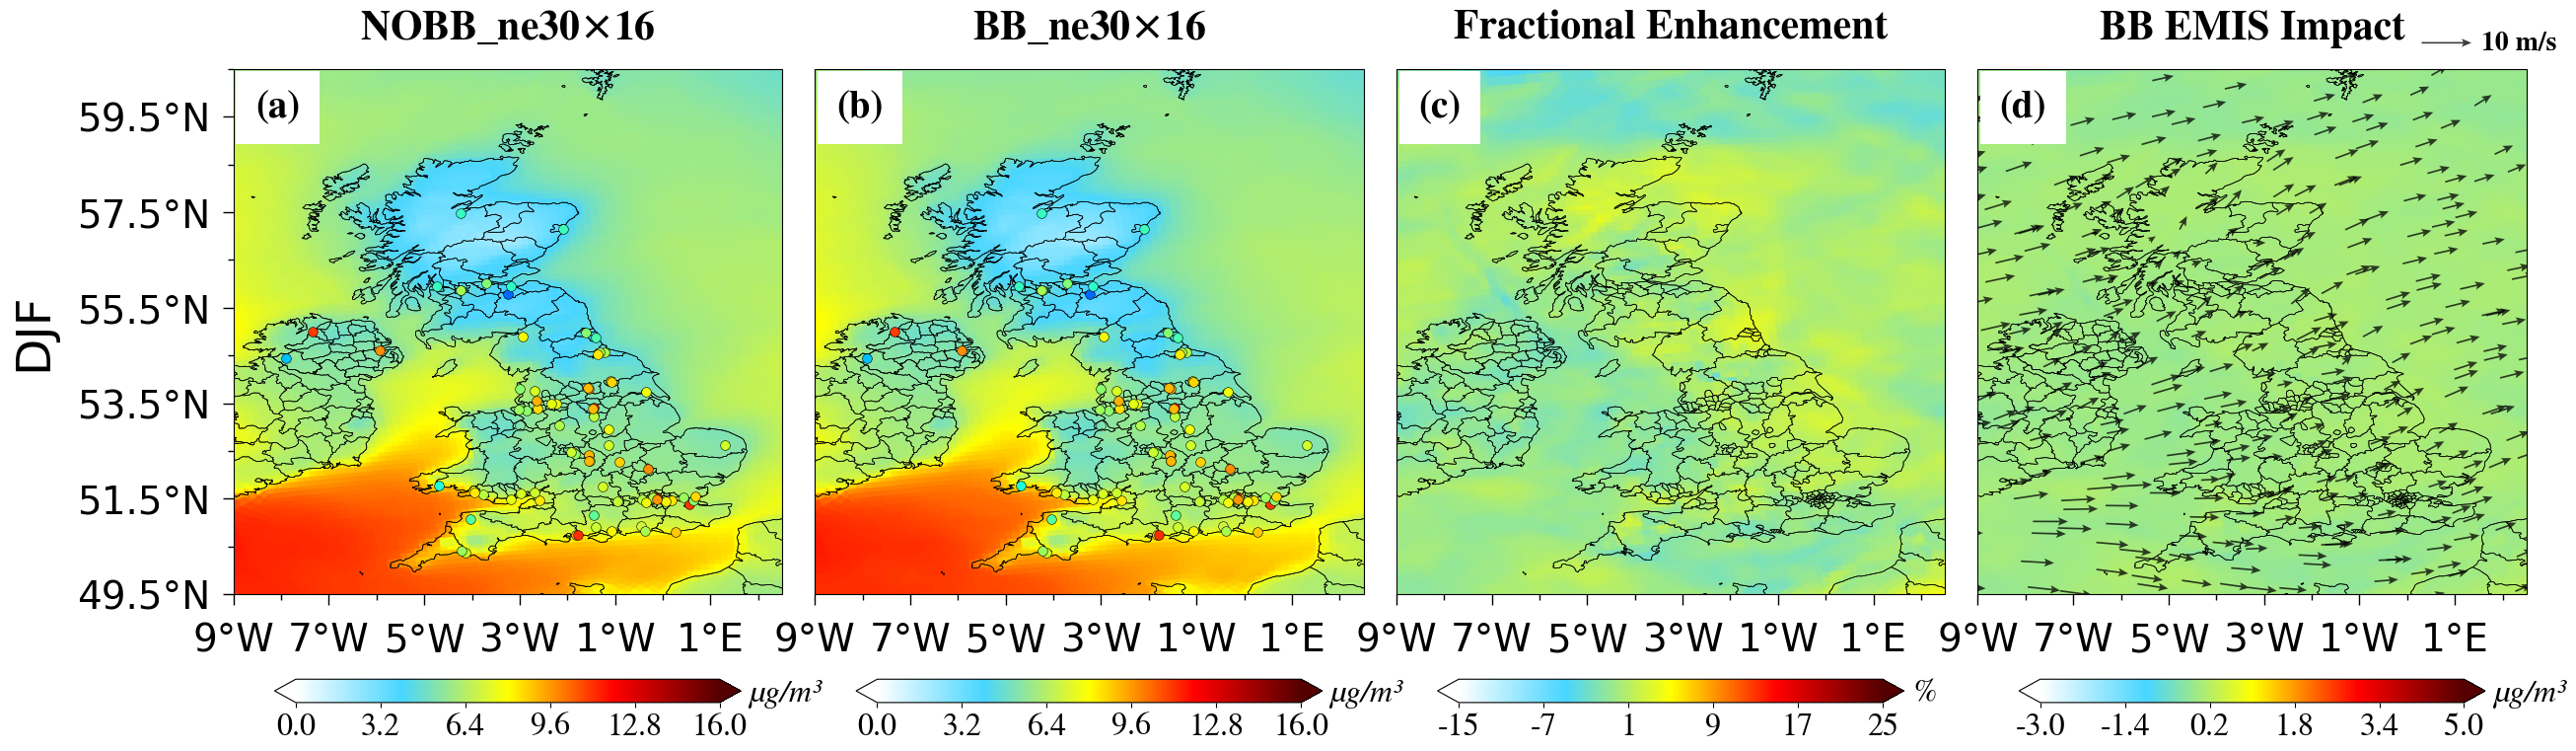

In [ ]:

df = pd.read_csv('/home/users/zhiyi/PROJECTS_ANALYSIS/extract_data/project_analysis/aurn_observation/PM25/pm2.5_filtered.csv', skiprows=1)
latobs = df['Latitude'].values
lonobs = df['Longitude'].values + 360

months = [
          '2018-12',
          '2018-01', 
          '2018-02']

selected_cols = []
for m in months:
    selected_cols.extend([col for col in df.columns if str(col).startswith(m)])

valobs = df[selected_cols].mean(axis=1).values
color_arr = valobs / 16
color_arr[color_arr > 1] = 1

pm25_data_NOBB = average_data_NOBB['PM25'].isel(lev=-1) * 1e9
pm25_data_BB   = average_data_BB['PM25'].isel(lev=-1) * 1e9
pm25_data_rel = (pm25_data_BB - pm25_data_NOBB) / pm25_data_NOBB * 100
pm25_data_diff = pm25_data_BB - pm25_data_NOBB

plot_settings = [
    (pm25_data_NOBB, r'NOBB_ne30$\times$16', 0, 16, 'µg/m³'),
    (pm25_data_BB, r'BB_ne30$\times$16', 0, 16, 'µg/m³'),
    (pm25_data_rel, 'Fractional Enhancement', -15, 25, '%'),
    (pm25_data_diff, 'BB EMIS Impact', -3, 5, 'µg/m³')
    # (pm25_data_diff, 'BB EMIS Impact', -3, 3, 'µg/m³')
]

with nc.Dataset(scrip_filename) as f:
    lon_scrip = f.variables['grid_center_lon'][:]
    lat_scrip = f.variables['grid_center_lat'][:]
u = average_data_BB['U'].isel(lev=-1).values  # (ncol,)
v = average_data_BB['V'].isel(lev=-1).values  # (ncol,)
step = 60
lon_plot = lon_scrip[::step]
lat_plot = lat_scrip[::step]
u_plot = u[::step]
v_plot = v[::step]

fig, axs = plt.subplots(1, 4, figsize=(30, 10), subplot_kw={'projection': ccrs.PlateCarree()})
for i, (data, title, vmin, vmax, unit) in enumerate(plot_settings):
    ax = axs.flat[i]
    p = Plot_2D(
        data,
        scrip_file=scrip_filename, pretty_tick=True,
        # lon_range=[-12, 4],
        # lat_range=[49, 62],
        # lon_range=[-8.5, 2.5],
        # lat_range=[49.5, 60.5],
        lon_range=[-9, 2.5],
        lat_range=[49.5, 60.5],
        lon_interval=2,
        lat_interval=2,
        resolution="10m",
        country=True, state=True, title=title,
        title_bold=True, unit=unit, 
        nticks=6,
        title_size=30,
        label_size=22,
        cmax=vmax, cmin=vmin, 
        # feature_line_lw=0.45,
        # grid_line=False,
        lonlat_line=False,
        shrink=0.85,
        pad=0.112,
        unit_offset=[0.05, 0],
        ax=ax
    )    
    if hasattr(p, 'cb'):
        p.cb.ax.tick_params(labelsize=23)
        for txt in p.cb.ax.texts:
            txt.set_fontsize(23)
    if i < 2:
        cmap = plt.colormaps['jet']
        for j in range(np.size(latobs)):
            ax.plot(
                lonobs[j], latobs[j],
                linestyle='none', marker="o", markersize=7,
                c=cmap(color_arr[j]),
                markeredgecolor="black", markeredgewidth=0.4,
                transform=ccrs.PlateCarree())

    font_prop = FontProperties(size=20, weight='bold')
    if i == 3:
        q = ax.quiver(
            lon_plot, lat_plot, u_plot, v_plot,
            scale=110, color='k', width=0.003, alpha=0.75,
            headaxislength=5, headwidth=5, headlength=6, 
            transform=ccrs.PlateCarree())
        
        ax.quiverkey(q, X=0.9, Y=1.05, U=10, label='10 m/s', 
                     labelpos='E', coordinates='axes', 
                     fontproperties=font_prop)

    if i == 0:
        ax.set_ylabel(
                      "DJF", 
                      fontsize=35, labelpad=15, 
                    #   fontsize=40, labelpad=15, weight='bold'
                      )
        ax.yaxis.set_tick_params(labelleft=True, labelright=False)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=28, pad=9, length=8, width=1, )
        ax.tick_params(axis='y', which='minor', labelsize=20*0.8, length=4, width=1)
        
    elif i == 3:
        ax.set_ylabel("")
        ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False)
    else:
        ax.set_ylabel("")
        ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False)

    ax.set_xlabel("", fontsize=18)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))    
    ax.tick_params(axis='x', which='major', labelsize=28, pad=12, length=8, width=1 )
    ax.tick_params(axis='x', which='minor', labelsize=20*0.8, length=4, width=1 )

fig.subplots_adjust(wspace=0.06,hspace=0.05)
for ax in axs.flat:
    ax.set_title(ax.get_title(), fontsize=30, weight='bold', pad=22)

# 01
letters = ['(a)', '(b)', '(c)', '(d)']
for i, ax in enumerate(axs.flat):
    ax.text(
            # 0.039, 0.95,
            0.040, 0.96, 
            letters[i], transform=ax.transAxes, 
            fontsize=28, va='top', 
            ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.5',  alpha=1))

def lon_formatter(x, pos=None):
    if x == 0:
        return "0°"
    elif x > 0:
        return f"{x:.0f}°E"
    else:
        return f"{abs(x):.0f}°W"
def lat_formatter(y, pos=None):
    if y == 0:
        return "0°"
    elif y > 0:
        return f"{y:.1f}°N"
    else:
        return f"{abs(y):.1f}°S"

for _ax in axs.flat:
    _ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
    _ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))



done


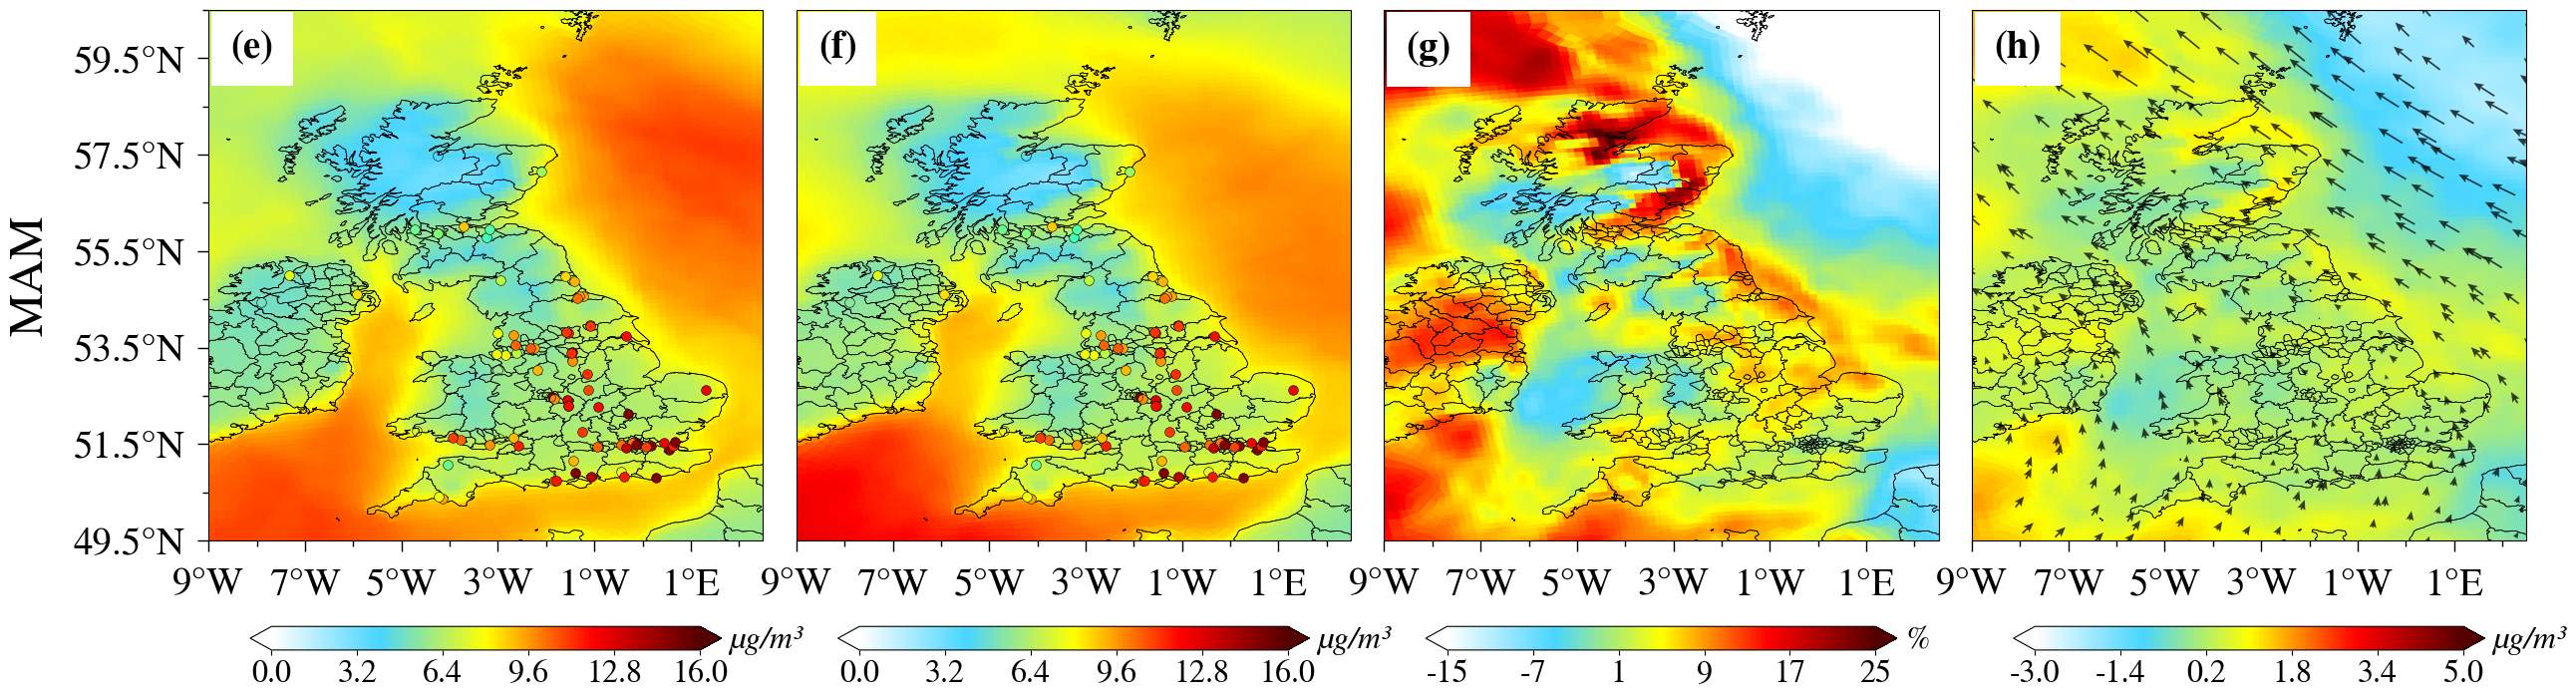

In [ ]:

file_paths_NOBB = [
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-03.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-04.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-05.nc"]

datasets_NOBB = [xr.open_dataset(file) for file in file_paths_NOBB]
combined_NOBB = xr.concat(datasets_NOBB, dim="time")
average_data_NOBB = combined_NOBB.mean(dim="time")

file_paths_BB = [
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-03.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-04.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-05.nc"]

datasets_BB = [xr.open_dataset(file) for file in file_paths_BB]
combined_BB = xr.concat(datasets_BB, dim="time")
average_data_BB = combined_BB.mean(dim="time")
print('done')

df = pd.read_csv('/home/users/zhiyi/PROJECTS_ANALYSIS/extract_data/project_analysis/aurn_observation/PM25/pm2.5_filtered.csv', skiprows=1)
latobs = df['Latitude'].values
lonobs = df['Longitude'].values + 360

months = [
          '2018-03',
          '2018-04', 
          '2018-05']

selected_cols = []
for m in months:
    selected_cols.extend([col for col in df.columns if str(col).startswith(m)])

valobs = df[selected_cols].mean(axis=1).values
color_arr = valobs / 16
color_arr[color_arr > 1] = 1

pm25_data_NOBB = average_data_NOBB['PM25'].isel(lev=-1) * 1e9
pm25_data_BB   = average_data_BB['PM25'].isel(lev=-1) * 1e9
pm25_data_rel = (pm25_data_BB - pm25_data_NOBB) / pm25_data_NOBB * 100
pm25_data_diff = pm25_data_BB - pm25_data_NOBB

plot_settings = [
    (pm25_data_NOBB, '', 0, 16, 'µg/m³'),
    (pm25_data_BB,   '', 0, 16, 'µg/m³'),
    (pm25_data_rel, '', -15, 25, '%'),
    (pm25_data_diff, '', -3, 5, 'µg/m³')
    # (pm25_data_diff, '', -3, 3, 'µg/m³')
]

with nc.Dataset(scrip_filename) as f:
    lon_scrip = f.variables['grid_center_lon'][:]
    lat_scrip = f.variables['grid_center_lat'][:]
u = average_data_BB['U'].isel(lev=-1).values
v = average_data_BB['V'].isel(lev=-1).values

step = 60
lon_plot = lon_scrip[::step]
lat_plot = lat_scrip[::step]
u_plot = u[::step]
v_plot = v[::step]

fig, axs = plt.subplots(1, 4, figsize=(30, 10), subplot_kw={'projection': ccrs.PlateCarree()})
for i, (data, title, vmin, vmax, unit) in enumerate(plot_settings):
    ax = axs.flat[i]
    p = Plot_2D(
        data,
        scrip_file=scrip_filename, pretty_tick=True,
        # lon_range=[-12, 4],
        # lat_range=[49, 62],
        # lon_range=[-8.5, 2.5],
        # lat_range=[49.5, 60.5],
        lon_range=[-9, 2.5],
        lat_range=[49.5, 60.5],
        lon_interval=2,
        lat_interval=2,
        resolution="10m",
        country=True, state=True, title=title,
        title_bold=True, unit=unit, 
        nticks=6,
        title_size=30,
        label_size=22,
        cmax=vmax, cmin=vmin, 
        # feature_line_lw=0.45,
        # grid_line=False,
        lonlat_line=False,
        shrink=0.85,
        pad=0.112,
        unit_offset=[0.05, 0],
        ax=ax
    )    
    if hasattr(p, 'cb'):
        p.cb.ax.tick_params(labelsize=23)
        for txt in p.cb.ax.texts:
            txt.set_fontsize(23)
    if i < 2:
        cmap = plt.colormaps['jet']
        for j in range(np.size(latobs)):
            ax.plot(
                lonobs[j], latobs[j],
                linestyle='none', marker="o", markersize=7,
                c=cmap(color_arr[j]),
                markeredgecolor="black", markeredgewidth=0.4,
                transform=ccrs.PlateCarree())

    font_prop = FontProperties(size=20, weight='bold')
    if i == 3:
        q = ax.quiver(
            lon_plot, lat_plot, u_plot, v_plot,
            scale=110, color='k', width=0.003, alpha=0.75,
            headaxislength=5, headwidth=5, headlength=6, 
            transform=ccrs.PlateCarree())
        
        ax.quiverkey(q, X=0.9, Y=1.05, U=10, label='10 m/s', 
                     labelpos='E', coordinates='axes', 
                     fontproperties=font_prop)

    if i == 0:
        ax.set_ylabel(
                      "MAM",
                      fontsize=35, labelpad=15, 
                    #   fontsize=40, labelpad=15, weight='bold'
                      )
        ax.yaxis.set_tick_params(labelleft=True, labelright=False)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=28, pad=9, length=8, width=1, )
        ax.tick_params(axis='y', which='minor', labelsize=20*0.8, length=4, width=1)
        
    elif i == 3:
        ax.set_ylabel("")
        ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False)
    else:
        ax.set_ylabel("")
        ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False)

    ax.set_xlabel("", fontsize=18)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))    
    ax.tick_params(axis='x', which='major', labelsize=28, pad=12, length=8, width=1 )
    ax.tick_params(axis='x', which='minor', labelsize=20*0.8, length=4, width=1 )

fig.subplots_adjust(wspace=0.06,hspace=0.05)
for ax in axs.flat:
    ax.set_title(ax.get_title(), fontsize=30, weight='bold', pad=22)

# 04
letters = ['(e)', '(f)', '(g)', '(h)']
for i, ax in enumerate(axs.flat):
    ax.text(
            # 0.039, 0.95,
            0.040, 0.96, 
            letters[i], transform=ax.transAxes, 
            fontsize=28, va='top', 
            ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.5',  alpha=1))

def lon_formatter(x, pos=None):
    if x == 0:
        return "0°"
    elif x > 0:
        return f"{x:.0f}°E"
    else:
        return f"{abs(x):.0f}°W"
def lat_formatter(y, pos=None):
    if y == 0:
        return "0°"
    elif y > 0:
        return f"{y:.1f}°N"
    else:
        return f"{abs(y):.1f}°S"

for _ax in axs.flat:
    _ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
    _ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))



done


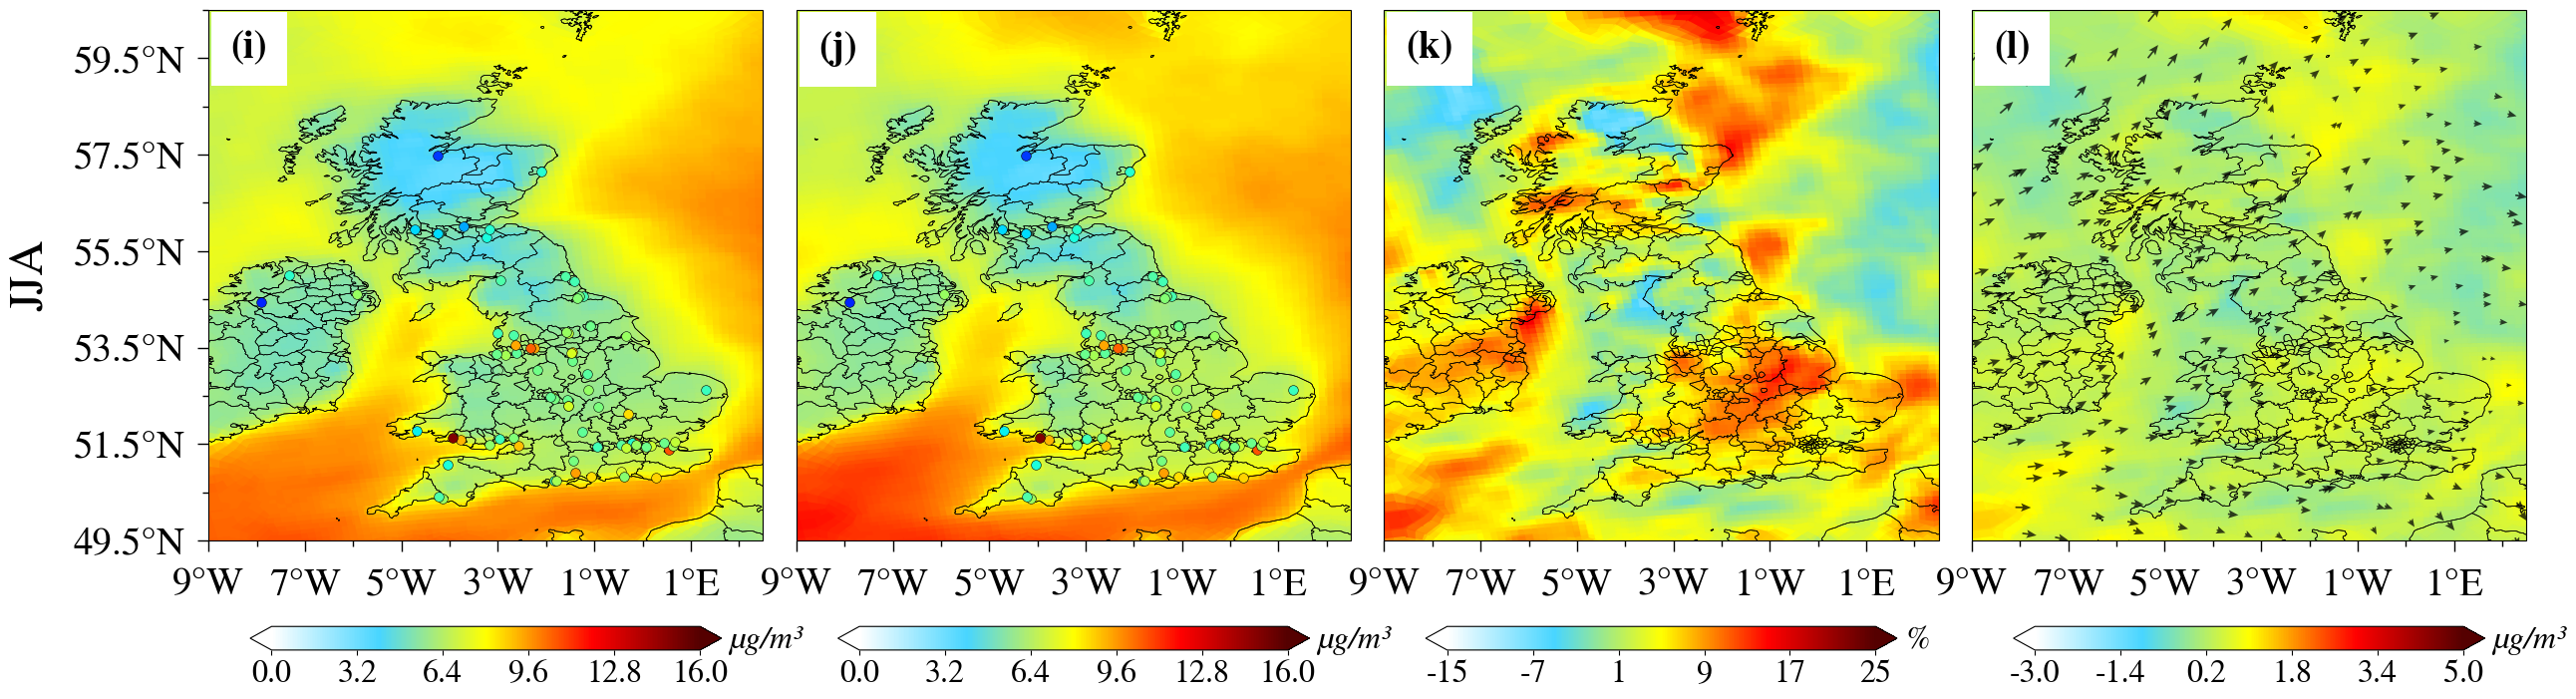

In [ ]:

file_paths_NOBB = [
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-06.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-07.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-08.nc"]

datasets_NOBB = [xr.open_dataset(file) for file in file_paths_NOBB]
combined_NOBB = xr.concat(datasets_NOBB, dim="time")
average_data_NOBB = combined_NOBB.mean(dim="time")

file_paths_BB = [
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-06.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-07.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-08.nc"]

datasets_BB = [xr.open_dataset(file) for file in file_paths_BB]
combined_BB = xr.concat(datasets_BB, dim="time")
average_data_BB = combined_BB.mean(dim="time")
print('done')

df = pd.read_csv('/home/users/zhiyi/PROJECTS_ANALYSIS/extract_data/project_analysis/aurn_observation/PM25/pm2.5_filtered.csv', skiprows=1)
latobs = df['Latitude'].values
lonobs = df['Longitude'].values + 360

months = [
          '2018-06',
          '2018-07', 
          '2018-08'
         ]

selected_cols = []
for m in months:
    selected_cols.extend([col for col in df.columns if str(col).startswith(m)])

valobs = df[selected_cols].mean(axis=1).values
color_arr = valobs / 16
color_arr[color_arr > 1] = 1

pm25_data_NOBB = average_data_NOBB['PM25'].isel(lev=-1) * 1e9
pm25_data_BB   = average_data_BB['PM25'].isel(lev=-1) * 1e9
pm25_data_rel = (pm25_data_BB - pm25_data_NOBB) / pm25_data_NOBB * 100
pm25_data_diff = pm25_data_BB - pm25_data_NOBB

plot_settings = [
    (pm25_data_NOBB, '', 0, 16, 'µg/m³'),
    (pm25_data_BB,   '', 0, 16, 'µg/m³'),
    (pm25_data_rel, '', -15, 25, '%'),
    (pm25_data_diff, '', -3, 5, 'µg/m³')
    # (pm25_data_diff, '', -3, 3, 'µg/m³')
]

with nc.Dataset(scrip_filename) as f:
    lon_scrip = f.variables['grid_center_lon'][:]
    lat_scrip = f.variables['grid_center_lat'][:]
u = average_data_BB['U'].isel(lev=-1).values  # (ncol,)
v = average_data_BB['V'].isel(lev=-1).values  # (ncol,)

step = 60
lon_plot = lon_scrip[::step]
lat_plot = lat_scrip[::step]
u_plot = u[::step]
v_plot = v[::step]

fig, axs = plt.subplots(1, 4, figsize=(30, 10), subplot_kw={'projection': ccrs.PlateCarree()})
for i, (data, title, vmin, vmax, unit) in enumerate(plot_settings):
    ax = axs.flat[i]
    p = Plot_2D(
        data,
        scrip_file=scrip_filename, pretty_tick=True,
        # lon_range=[-12, 4],
        # lat_range=[49, 62],
        # lon_range=[-8.5, 2.5],
        # lat_range=[49.5, 60.5],
        lon_range=[-9, 2.5],
        lat_range=[49.5, 60.5],
        lon_interval=2,
        lat_interval=2,
        resolution="10m",
        country=True, state=True, title=title,
        title_bold=True, unit=unit, 
        nticks=6,
        title_size=30,
        label_size=22,
        cmax=vmax, cmin=vmin, 
        # feature_line_lw=0.45,
        # grid_line=False,
        lonlat_line=False,
        shrink=0.85,
        pad=0.112,
        unit_offset=[0.05, 0],
        ax=ax
    )    
    if hasattr(p, 'cb'):
        p.cb.ax.tick_params(labelsize=23)
        for txt in p.cb.ax.texts:
            txt.set_fontsize(23)
    if i < 2:
        cmap = plt.colormaps['jet']
        for j in range(np.size(latobs)):
            ax.plot(
                lonobs[j], latobs[j],
                linestyle='none', marker="o", markersize=7,
                c=cmap(color_arr[j]),
                markeredgecolor="black", markeredgewidth=0.4,
                transform=ccrs.PlateCarree())

    font_prop = FontProperties(size=20, weight='bold')
    if i == 3:
        q = ax.quiver(
            lon_plot, lat_plot, u_plot, v_plot,
            scale=110, color='k', width=0.003, alpha=0.75,
            headaxislength=5, headwidth=5, headlength=6, 
            transform=ccrs.PlateCarree())
        
        ax.quiverkey(q, X=0.9, Y=1.05, U=10, label='10 m/s', 
                     labelpos='E', coordinates='axes', 
                     fontproperties=font_prop)

    if i == 0:
        ax.set_ylabel(
                      "JJA",
                      fontsize=35, labelpad=15, 
                    #   fontsize=40, labelpad=15, weight='bold'
                      )
        ax.yaxis.set_tick_params(labelleft=True, labelright=False)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=28, pad=9, length=8, width=1, )
        ax.tick_params(axis='y', which='minor', labelsize=20*0.8, length=4, width=1)
        
    elif i == 3:
        ax.set_ylabel("")
        ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False)
    else:
        ax.set_ylabel("")
        ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False)

    ax.set_xlabel("", fontsize=18)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))    
    ax.tick_params(axis='x', which='major', labelsize=28, pad=12, length=8, width=1 )
    ax.tick_params(axis='x', which='minor', labelsize=20*0.8, length=4, width=1 )

fig.subplots_adjust(wspace=0.06,hspace=0.05)
for ax in axs.flat:
    ax.set_title(ax.get_title(), fontsize=30, weight='bold', pad=22)
# 07
letters = ['(i)', '(j)', '(k)', '(l)']
for i, ax in enumerate(axs.flat):
    ax.text(
            # 0.039, 0.95,
            0.040, 0.96, 
            letters[i], transform=ax.transAxes, 
            fontsize=28, va='top', 
            ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.5',  alpha=1))

def lon_formatter(x, pos=None):
    if x == 0:
        return "0°"
    elif x > 0:
        return f"{x:.0f}°E"
    else:
        return f"{abs(x):.0f}°W"
def lat_formatter(y, pos=None):
    if y == 0:
        return "0°"
    elif y > 0:
        return f"{y:.1f}°N"
    else:
        return f"{abs(y):.1f}°S"

for _ax in axs.flat:
    _ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
    _ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))


done


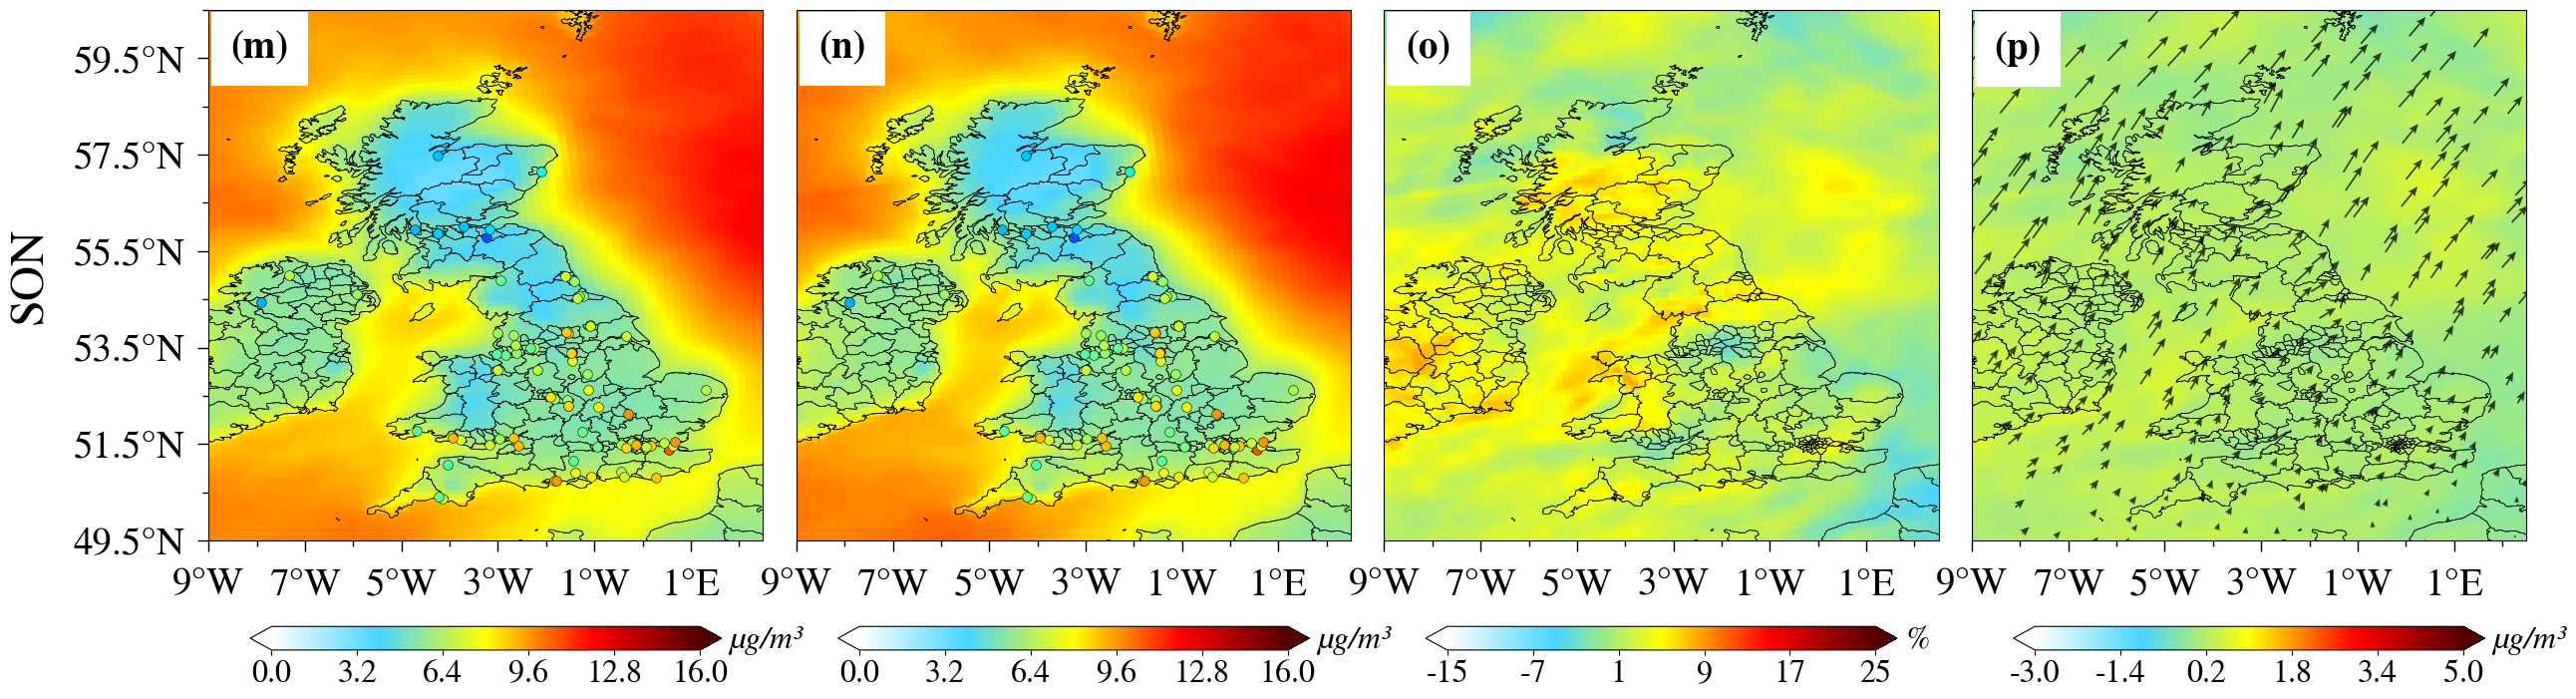

In [ ]:

file_paths_NOBB = [
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-09.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-10.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h4.2018-11.nc"]

datasets_NOBB = [xr.open_dataset(file) for file in file_paths_NOBB]
combined_NOBB = xr.concat(datasets_NOBB, dim="time")
average_data_NOBB = combined_NOBB.mean(dim="time")

file_paths_BB = [
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-09.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-10.nc",
    "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h4.2018-11.nc"]

datasets_BB = [xr.open_dataset(file) for file in file_paths_BB]
combined_BB = xr.concat(datasets_BB, dim="time")
average_data_BB = combined_BB.mean(dim="time")
print('done')

df = pd.read_csv('/home/users/zhiyi/PROJECTS_ANALYSIS/extract_data/project_analysis/aurn_observation/PM25/pm2.5_filtered.csv', skiprows=1)
latobs = df['Latitude'].values
lonobs = df['Longitude'].values + 360

months = [
          '2018-09',
          '2018-10', 
          '2018-11']

selected_cols = []
for m in months:
    selected_cols.extend([col for col in df.columns if str(col).startswith(m)])

valobs = df[selected_cols].mean(axis=1).values
color_arr = valobs / 16
color_arr[color_arr > 1] = 1

pm25_data_NOBB = average_data_NOBB['PM25'].isel(lev=-1) * 1e9
pm25_data_BB   = average_data_BB['PM25'].isel(lev=-1) * 1e9
pm25_data_rel = (pm25_data_BB - pm25_data_NOBB) / pm25_data_NOBB * 100
pm25_data_diff = pm25_data_BB - pm25_data_NOBB

plot_settings = [
    (pm25_data_NOBB, '', 0, 16, 'µg/m³'),
    (pm25_data_BB,   '', 0, 16, 'µg/m³'),
    (pm25_data_rel, '', -15, 25, '%'),
    (pm25_data_diff, '', -3, 5, 'µg/m³')
    # (pm25_data_diff, '', -3, 3, 'µg/m³')
]

with nc.Dataset(scrip_filename) as f:
    lon_scrip = f.variables['grid_center_lon'][:]
    lat_scrip = f.variables['grid_center_lat'][:]
u = average_data_BB['U'].isel(lev=-1).values  # (ncol,)
v = average_data_BB['V'].isel(lev=-1).values  # (ncol,)

step = 60
lon_plot = lon_scrip[::step]
lat_plot = lat_scrip[::step]
u_plot = u[::step]
v_plot = v[::step]

fig, axs = plt.subplots(1, 4, figsize=(30, 10), subplot_kw={'projection': ccrs.PlateCarree()})
for i, (data, title, vmin, vmax, unit) in enumerate(plot_settings):
    ax = axs.flat[i]
    p = Plot_2D(
        data,
        scrip_file=scrip_filename, pretty_tick=True,
        # lon_range=[-12, 4],
        # lat_range=[49, 62],
        # lon_range=[-8.5, 2.5],
        # lat_range=[49.5, 60.5],
        lon_range=[-9, 2.5],
        lat_range=[49.5, 60.5],
        lon_interval=2,
        lat_interval=2,
        resolution="10m",
        country=True, state=True, title=title,
        title_bold=True, unit=unit, 
        nticks=6,
        title_size=30,
        label_size=22,
        cmax=vmax, cmin=vmin, 
        # feature_line_lw=0.45,
        # grid_line=False,
        lonlat_line=False,
        shrink=0.85,
        pad=0.112,
        unit_offset=[0.05, 0],
        ax=ax
    )    
    if hasattr(p, 'cb'):
        p.cb.ax.tick_params(labelsize=23)
        for txt in p.cb.ax.texts:
            txt.set_fontsize(23)
    if i < 2:
        cmap = plt.colormaps['jet']
        for j in range(np.size(latobs)):
            ax.plot(
                lonobs[j], latobs[j],
                linestyle='none', marker="o", markersize=7,
                c=cmap(color_arr[j]),
                markeredgecolor="black", markeredgewidth=0.4,
                transform=ccrs.PlateCarree())

    font_prop = FontProperties(size=20, weight='bold')
    if i == 3:
        q = ax.quiver(
            lon_plot, lat_plot, u_plot, v_plot,
            scale=110, color='k', width=0.003, alpha=0.75,
            headaxislength=5, headwidth=5, headlength=6, 
            transform=ccrs.PlateCarree())
        
        ax.quiverkey(q, X=0.9, Y=1.05, U=10, label='10 m/s', 
                     labelpos='E', coordinates='axes', 
                     fontproperties=font_prop)

    if i == 0:
        ax.set_ylabel(
                       "SON",
                      fontsize=35, labelpad=15, 
                    #   fontsize=40, labelpad=15, weight='bold'
                      )
        ax.yaxis.set_tick_params(labelleft=True, labelright=False)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=28, pad=9, length=8, width=1, )
        ax.tick_params(axis='y', which='minor', labelsize=20*0.8, length=4, width=1)
        
    elif i == 3:
        ax.set_ylabel("")
        ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False)
    else:
        ax.set_ylabel("")
        ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False)

    ax.set_xlabel("", fontsize=18)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))    
    ax.tick_params(axis='x', which='major', labelsize=28, pad=12, length=8, width=1 )
    ax.tick_params(axis='x', which='minor', labelsize=20*0.8, length=4, width=1 )

fig.subplots_adjust(wspace=0.06,hspace=0.05)
for ax in axs.flat:
    ax.set_title(ax.get_title(), fontsize=30, weight='bold', pad=22)

letters = ['(m)', '(n)', '(o)', '(p)']
for i, ax in enumerate(axs.flat):
    ax.text(
            # 0.039, 0.95,
            0.040, 0.96, 
            letters[i], transform=ax.transAxes, 
            fontsize=28, va='top', 
            ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.5',  alpha=1))

def lon_formatter(x, pos=None):
    if x == 0:
        return "0°"
    elif x > 0:
        return f"{x:.0f}°E"
    else:
        return f"{abs(x):.0f}°W"
def lat_formatter(y, pos=None):
    if y == 0:
        return "0°"
    elif y > 0:
        return f"{y:.1f}°N"
    else:
        return f"{abs(y):.1f}°S"

for _ax in axs.flat:
    _ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
    _ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))

